In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics import f1_score
from sklearn.svm import SVC, LinearSVC
import re 
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt

import warnings

warnings.filterwarnings("ignore", category=UserWarning, module="sklearn")   

In [2]:
df = pd.read_csv("development.csv")

category_map = {
    0: "International News",
    1: "Business",
    2: "Technology",
    3: "Entertainment",
    4: "Sports",
    5: "General News",
    6: "Health"
}

print(df.dtypes)
print(df.shape)

Id            int64
source       object
title        object
article      object
page_rank     int64
timestamp    object
label         int64
dtype: object
(79997, 7)


In [3]:
#remove nan

df.dropna(inplace=True)
df.isna().sum().sum()
print(df.shape)

(79995, 7)


# Definizione di clean text

In [4]:
def clean_text_without_url(text):
    if not isinstance(text, str):
        return ""

    # capturing alt captions from HTML before stripping tags
    captions = " ".join(re.findall(r'alt="([^"]*)"', text))
    captions = re.sub(r'[^a-zA-Z\s]', ' ', captions)

    # removing the URL messages 
    text_no_links = re.sub(r'https?://\S+', ' ', text)

    # remove HTML tags
    text_without_tags = re.sub(r'<[^>]+>', ' ', text_no_links)

    # keep information about money simbols
    text_without_tags = re.sub(
        r'[$€£¥]',
        ' MONEYAMOUNT ',
        text_without_tags
    )

    # this removes punctuation, numbers
    text_final = re.sub(r"[^a-zA-Z\s]", ' ', text_without_tags)

    combined = text_final  + " " + captions

    # 6. lower casse and extra whitespace removal
    return re.sub(r'\s+', ' ', combined).strip().lower()

In [5]:
clean_text = clean_text_without_url

In [6]:
def cleaner_applyer(df):
    # cleans the text and craetes the combined text to be vectorized 
    df['title'] = df['title'].fillna('').apply(clean_text)
    df['article'] = df['article'].fillna('').apply(clean_text)
    df['source'] = df['source'].fillna('')
    df['combined_text'] = df['title'] + " " + df['article']
    df['combined_text2'] = df['title'] + " " + df['article']

cleaner_applier = cleaner_applyer


In [7]:
from sklearn.base import BaseEstimator, TransformerMixin
# this classi was desined to easily put all the cleaning toghether

class TextCleanerTransformer(BaseEstimator, TransformerMixin):
    def __init__(self):
        pass
    
    def fit(self, X, y=None):
        return self 
    
    def transform(self, X):
        
        X = X.copy()
            
        cleaner_applier(X)
        
        return X

# definizione di lemmatizer e vectorizer

In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer 
from nltk.tokenize import word_tokenize 
from nltk.stem.wordnet import WordNetLemmatizer 
from nltk.corpus import stopwords as sw 
import nltk
from nltk.stem import PorterStemmer

class LemmaTokenizerGood(object): 
    def __init__(self): 
        self.lemmatizer = WordNetLemmatizer() 
        # Carichiamo le stopword una volta sola per efficienza
        self.stop_words = set(sw.words('english'))
    
    def __call__(self, document): 
        lemmas = [] 
        for t in word_tokenize(document): 
            t = t.lower().strip()
            
            # FILTRO: Se la parola è una stopword o è troppo corta, la scartiamo SUBITO
            if t.isalpha() and t not in self.stop_words and len(t) > 2:
                # Solo se supera il filtro viene lemmatizzata
                lemma = self.lemmatizer.lemmatize(t) 
                lemmas.append(lemma)
                
        return lemmas
    

lemmaTokenizer = LemmaTokenizerGood()   
text_transformer1 = TfidfVectorizer(
    max_features=250000, 
    tokenizer=lemmaTokenizer, 
    stop_words=None, 
    ngram_range=(1, 2), 
    sublinear_tf=True, 
    norm='l2', 
    use_idf = True,
    min_df=3, 
    max_df=0.1)  

# pulizia dei rumori 

In [9]:
# ----------------------------
# cleaning applyer
# ----------------------------

remove_short = True
remove_long = False
remove_duplicates = False
remove_duplicates2 = True
# 1. Filtro lunghezza (eseguito PRIMA della separazione X, y)


if remove_duplicates:
    occurrence_count = df.groupby("article").cumcount()

    # Teniamo solo la prima occorrenza (dove il contatore è 0)
    mask_keep_first = (occurrence_count == 0)

    # Calcoliamo quanti erano i duplicati totali prima di filtrare
    # (quelli che hanno un conteggio totale > 1)
    total_duplicates_removed = (df.groupby("article")["article"].transform("count") > 1).sum() - mask_keep_first[df.groupby("article")["article"].transform("count") > 1].sum()

    df = df[mask_keep_first].reset_index(drop=True)

    print(f"dup -> {total_duplicates_removed} extra copies removed (1 copy kept)")

if remove_duplicates2:
    len_prima = df.shape[0]
    # Rimuove i duplicati basandosi sulla colonna 'article' e tiene la prima occorrenza
    df = df.drop_duplicates(subset=['article'], keep='first').reset_index(drop=True)
    len_dopo = df.shape[0]
    print(f"dup -> {len_prima - len_dopo} extra copies removed (1 copy kept)")


#rimozioni articoli troppo lunghi
if remove_long:
    lenght = np.array([len(article) for article in df['article']])
    p90_value = np.percentile(lenght, 99.9)
    print(f"max len accepted = {p90_value}")
    mask_lenght = lenght <= p90_value
    filtered_lenght = lenght[mask_lenght]

    # If you want to filter your original DataFrame
    df = df[df['article'].str.len() <= p90_value].reset_index(drop=True)

    print(f"too long -> {(~mask_lenght).sum()} has been removed")

if remove_short:
    mask_len = df['article'].str.len() >= 50
    df = df[mask_len].copy() 
    print(f"too short -> {(~mask_len).sum()} has been removed")

    df = df.reset_index(drop=True)



    

df = df.reset_index(drop = True)


dup -> 5602 extra copies removed (1 copy kept)
too short -> 707 has been removed


# definizione dei trasformatori


In [10]:
num_transformer = StandardScaler()
source_transformer = OneHotEncoder(handle_unknown='ignore')
text_transformer_classic_char = TfidfVectorizer(analyzer='char',
    ngram_range=(3, 5),
    min_df=5,
    max_df=0.5,
    max_features=120_000,
    sublinear_tf=True,
    norm='l2',
    use_idf=True)

In [11]:
# ---------------------------
# preprocessor applier
# ---------------------------
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler 
from sklearn.feature_selection import SelectKBest, chi2

preprocessor = ColumnTransformer(
    transformers=[
        ('text', text_transformer1, 'combined_text'),
        ('char', text_transformer_classic_char, 'combined_text2'), 
        ('source', source_transformer, ['source']),
        ('pagerank', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), ['page_rank']),
        ('year', OneHotEncoder(handle_unknown='ignore'), ['year']),
        ('lenght', MinMaxScaler(), ['article_len'])
        
    ], remainder='drop'
)


pipeline_preprocessing = Pipeline([
    ('preprocessor', preprocessor),
    
    # ('selector', SelectKBest(chi2, 'all'))
    
])

# inizio definizione di X e y e pipeline

In [12]:
cleaner = TextCleanerTransformer()
df = cleaner.fit_transform(df)
df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')
df['year'] = df['timestamp'].dt.year
df['year'] = df['year'].fillna(0)
df['article_len'] = df['article'].fillna('').str.len()
X = df.drop(columns=['label'])
y = df['label']



df.isna().sum().sum()

np.int64(25350)

In [13]:
linear_svc = LinearSVC()

pipe = Pipeline([
    ('preprocessor_pipeline', pipeline_preprocessing),
    ("clf", linear_svc)
])

# {'clf__C': 0.075, 'clf__class_weight': 'balanced', 'preprocessor_pipeline__preprocessor__char__max_df': 0.06, 'preprocessor_pipeline__preprocessor__char__max_features': 120000, 'preprocessor_pipeline__preprocessor__char__min_df': 5, 'preprocessor_pipeline__preprocessor__char__ngram_range': (3, 5), 'preprocessor_pipeline__preprocessor__char__sublinear_tf': True, 'preprocessor_pipeline__preprocessor__char__use_idf': True, 'preprocessor_pipeline__preprocessor__text__binary': False, 'preprocessor_pipeline__preprocessor__text__max_df': 0.15, 'preprocessor_pipeline__preprocessor__text__max_features': 200000, 'preprocessor_pipeline__preprocessor__text__min_df': 5, 'preprocessor_pipeline__preprocessor__text__ngram_range': (1, 3), 'preprocessor_pipeline__preprocessor__text__sublinear_tf': True}
0.7012822267744704

In [14]:

best_pipeline_params = { 'preprocessor_pipeline__preprocessor__text__sublinear_tf' : True,
'preprocessor_pipeline__preprocessor__text__ngram_range' : (1, 3),
'preprocessor_pipeline__preprocessor__text__min_df' : 5,
'preprocessor_pipeline__preprocessor__text__max_features' : 200000,
'preprocessor_pipeline__preprocessor__text__max_df' : 0.15,
'preprocessor_pipeline__preprocessor__text__use_idf' : True,
# 'preprocessor_pipeline__preprocessor__text__smooth_idf' : True,
'preprocessor_pipeline__preprocessor__text__binary': False,
'preprocessor_pipeline__preprocessor__text__norm' : 'l2',


'clf__C' : 0.075,
'clf__class_weight' : 'balanced', # or balanced or None
# 'preprocessor_pipeline__selector__k' : 'all',  # 'all' se voglio tutte

# char preprocessor

'preprocessor_pipeline__preprocessor__char__sublinear_tf' : True,
'preprocessor_pipeline__preprocessor__char__ngram_range' : (3, 5),
'preprocessor_pipeline__preprocessor__char__min_df' : 5,
'preprocessor_pipeline__preprocessor__char__max_features' : 120_000,
'preprocessor_pipeline__preprocessor__char__max_df' : 0.06,
'preprocessor_pipeline__preprocessor__char__use_idf' : True,
'preprocessor_pipeline__preprocessor__char__smooth_idf' : True,
'preprocessor_pipeline__preprocessor__char__norm' : 'l2',

}

final_pipeline = pipe.set_params(**best_pipeline_params)

# inizio test e creazione delle submission

In [15]:

final_pipeline.fit(X, y)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor_pipeline', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or 

## grafici iniziali per vedere dove si confonde

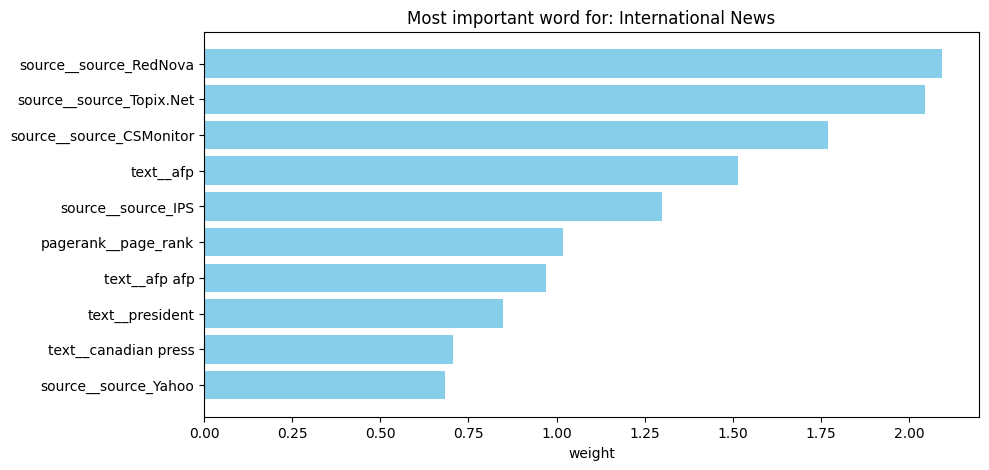

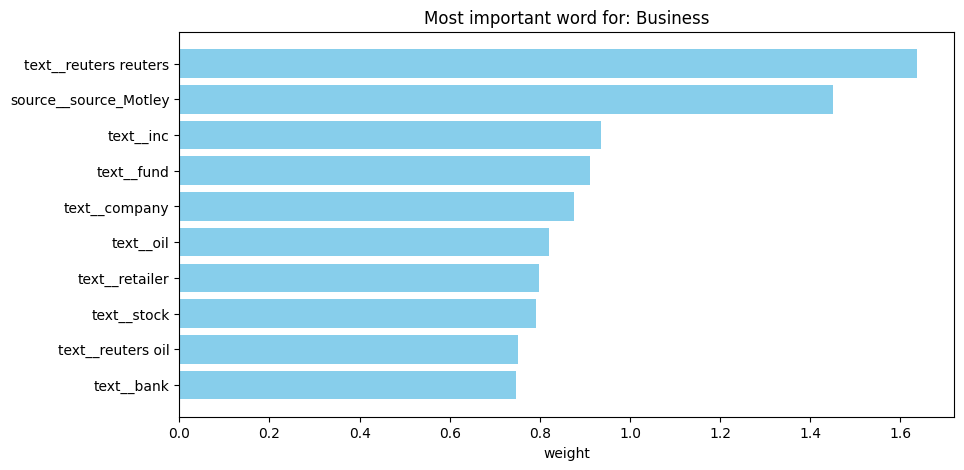

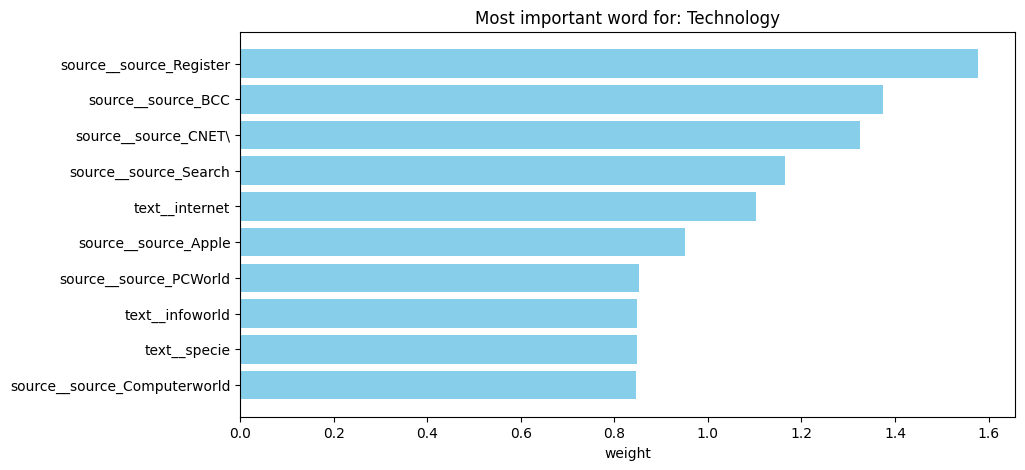

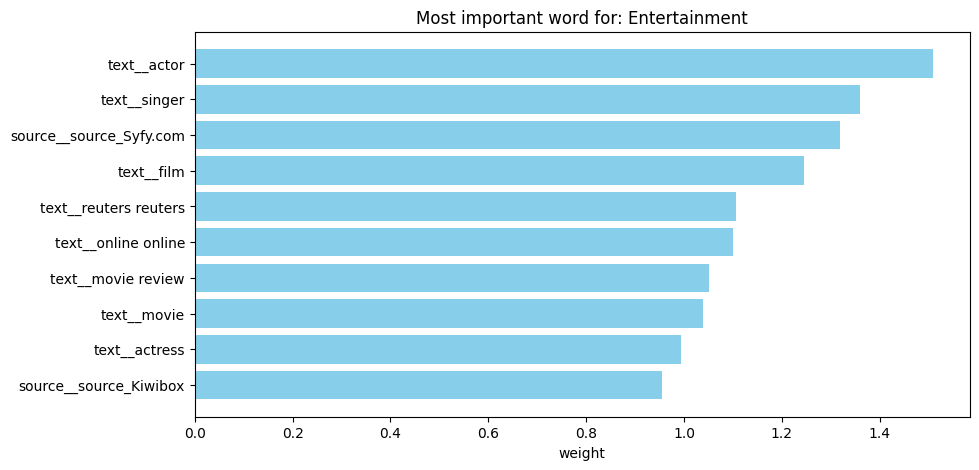

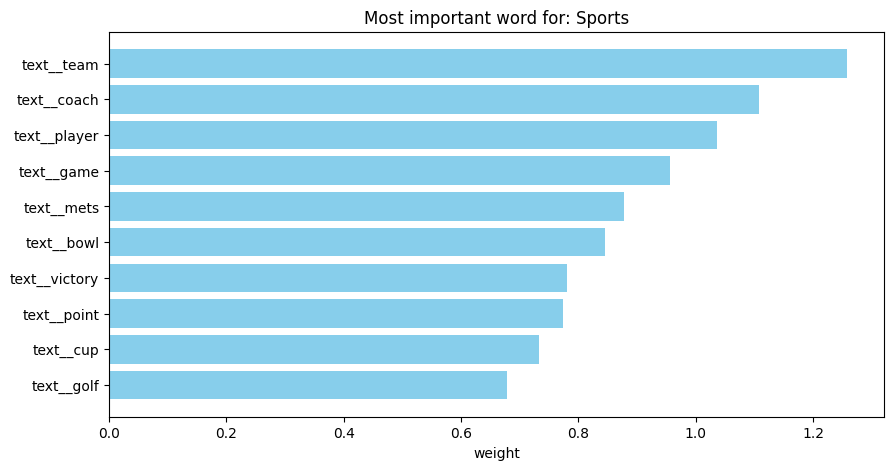

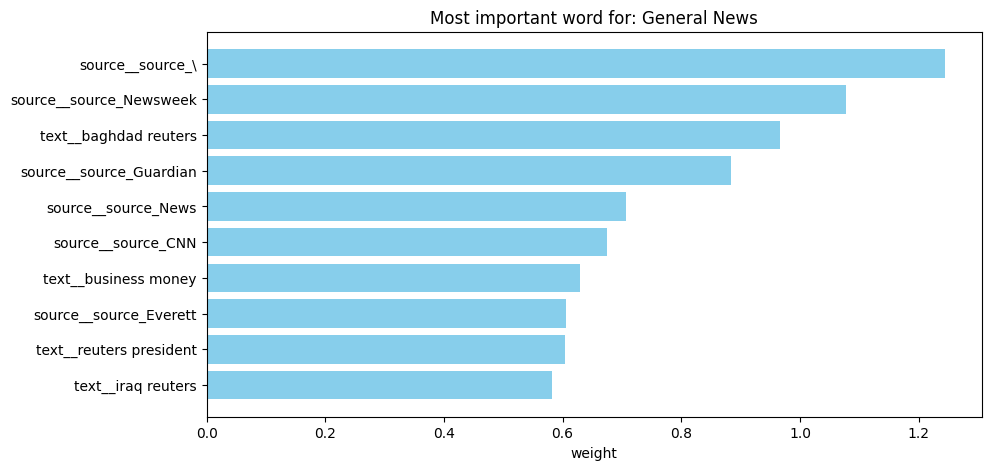

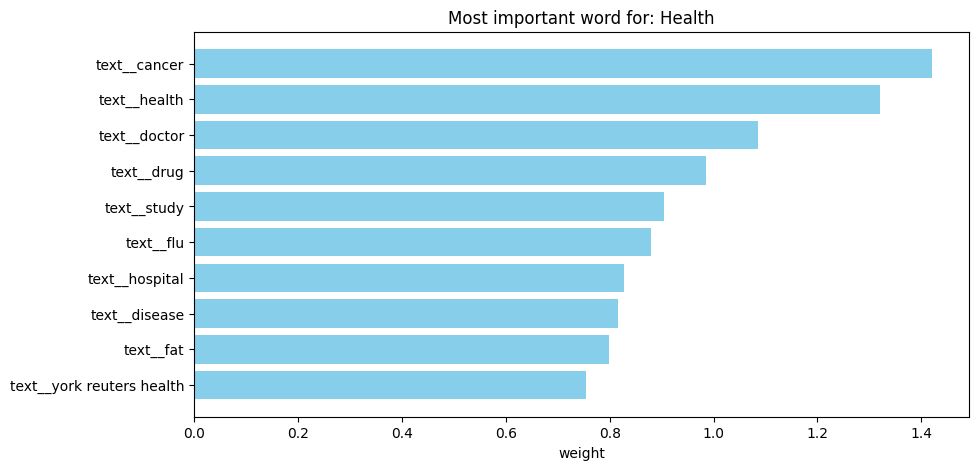

In [16]:
vectorizer = final_pipeline.named_steps['preprocessor_pipeline']
model = final_pipeline.named_steps['clf']

# in this way i get the feature of the text
feature_names = vectorizer.get_feature_names_out()

# SVC coefficients
coefficients = model.coef_

category_names = list(category_map.values())

for i, category in enumerate(category_names):
    # coefficient per class
    coef_row = coefficients[i]
    
    # top 10 relevant feature for the model
    top_indices = np.argsort(coef_row)[-10:]
    

    top_words = [feature_names[idx] for idx in top_indices]
    top_weights = coef_row[top_indices]

    # plotting
    plt.figure(figsize=(10, 5))
    plt.barh(top_words, top_weights, color='skyblue')
    plt.title(f"Most important word for: {category}")
    plt.xlabel("weight")
    plt.show()

# INIZIO TEST SU DATASET SCONOSCIUTO

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

final_pipeline.fit(X_train, y_train)

y_pred = final_pipeline.predict(X_test)

print(f1_score(y_pred, y_test, average='macro'))

0.6941999927988366


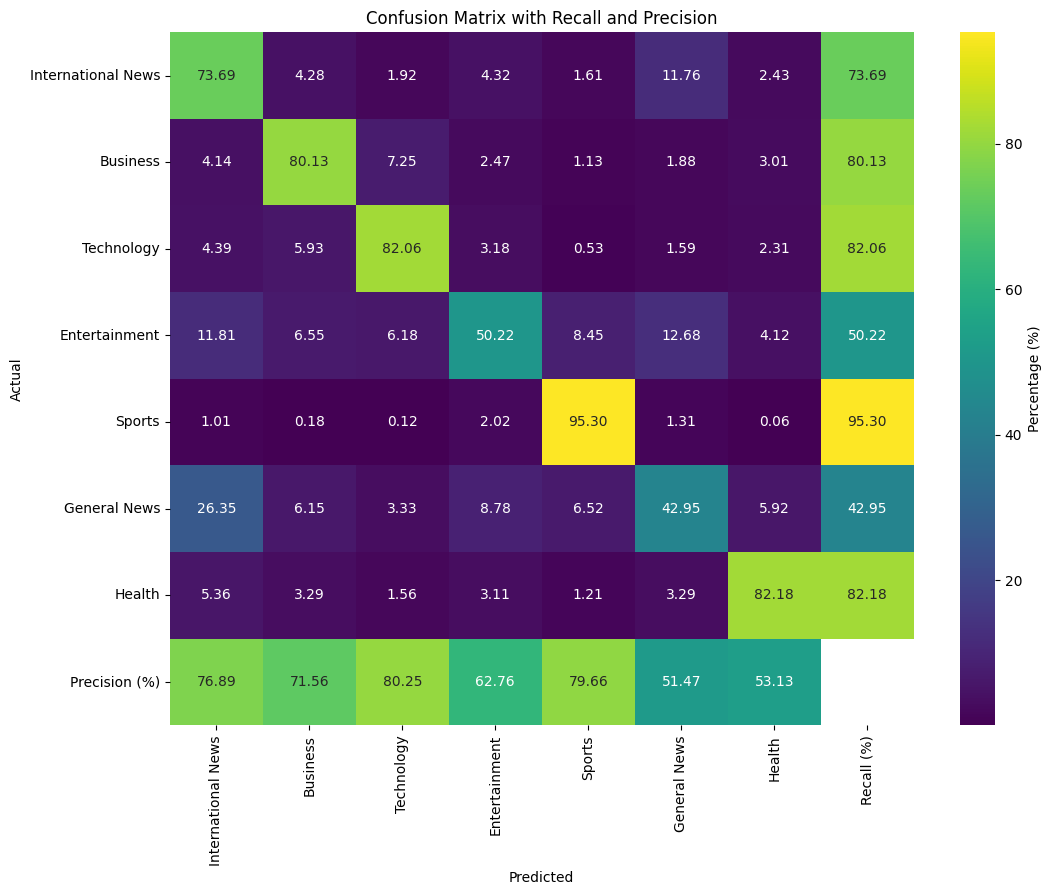

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, precision_score, recall_score


labels = [category_map[i] for i in sorted(category_map.keys())]
n_classes = len(labels)

# confusion matrix with percentages
cm = confusion_matrix(y_test, y_pred)
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100 

# precisions and recalls
recalls = recall_score(y_test, y_pred, average=None) * 100 
precisions = precision_score(y_test, y_pred, average=None) * 100 

# support dataframe to build the matrix
cm_df = pd.DataFrame(cm_percent, index=labels, columns=labels)

cm_df['Recall (%)'] = recalls

precision_row = list(precisions) + [np.nan] 
cm_df.loc['Precision (%)'] = precision_row

plt.figure(figsize=(12,9))
sns.heatmap(cm_df, annot=True, fmt=".2f", cmap='viridis', cbar_kws={'label': 'Percentage (%)'})
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix with Recall and Precision')
plt.show()


In [19]:
mask = y_test != y_pred

X_error = X_test.loc[mask == True].reset_index(drop = True)
X_error.reset_index(drop=True)
y_error = y_test[mask]
y_pred_error = y_pred[mask]

y_mapped = pd.Series(y_error).map(category_map).reset_index(drop = True)
y_mapped.name = "True_Label_Name"
y_pred_mapped = pd.Series(y_pred_error).map(category_map).reset_index(drop = True)
y_pred_mapped.name = "predicted"

prediction_errors = pd.concat([X_error, y_pred_mapped, y_mapped], axis=1)

prediction_errors.head(10)


,Id,source,title,article,page_rank,timestamp,combined_text,combined_text2,year,article_len,predicted,True_Label_Name
0,75836,WZZM,pfizer won t pull celebrex,pfizer is stopping tv and print ads for arthri...,5,NaT,pfizer won t pull celebrex pfizer is stopping ...,pfizer won t pull celebrex pfizer is stopping ...,0.0,207,Health,Business
1,16418,New,sweet bloody smell of success,greatness hovers just outside american gangste...,5,2007-11-04 00:42:42,sweet bloody smell of success greatness hovers...,sweet bloody smell of success greatness hovers...,2007.0,77,Business,Entertainment
2,18849,Reuters,e coli found in cattle feces in spinach probe,san francisco reuters california officials hav...,5,2006-10-04 03:44:04,e coli found in cattle feces in spinach probe ...,e coli found in cattle feces in spinach probe ...,2006.0,277,Health,International News
3,35035,Times,highest us troop level ahead of fallujah assault,america has increased its troop numbers in ira...,5,2004-11-01 14:41:18,highest us troop level ahead of fallujah assau...,highest us troop level ahead of fallujah assau...,2004.0,177,Entertainment,General News
4,71996,Reuters,serbs snatch war crimes general gesture to west,belgrade reuters a bosnian serb general accuse...,5,2007-06-01 13:32:50,serbs snatch war crimes general gesture to wes...,serbs snatch war crimes general gesture to wes...,2007.0,227,International News,General News
5,25619,Hi,two guards appear in court martial hearings,baghdad preliminary court martial proceedings ...,5,NaT,two guards appear in court martial hearings ba...,two guards appear in court martial hearings ba...,0.0,155,International News,Entertainment
6,10325,BBC,blackstone float set to proceed,the partial stock market listing of private eq...,5,2007-06-21 16:01:50,blackstone float set to proceed the partial st...,blackstone float set to proceed the partial st...,2007.0,112,Business,International News
7,3553,Yahoo,natural gas blast kills man in kansas ap,ap a construction crew ruptured a natural gas ...,5,2006-09-30 08:27:26,natural gas blast kills man in kansas ap ap a ...,natural gas blast kills man in kansas ap ap a ...,2006.0,142,International News,Technology
8,76960,sportinglife.com,mcleish offers no excuses,rangers manager alex mcleish admitted his side...,5,NaT,mcleish offers no excuses rangers manager alex...,mcleish offers no excuses rangers manager alex...,0.0,198,Sports,Entertainment
9,20658,Manchester,google gets personal,internet giant google has taken its searching ...,5,2004-10-15 18:54:24,google gets personal internet giant google has...,google gets personal internet giant google has...,2004.0,205,Technology,Entertainment


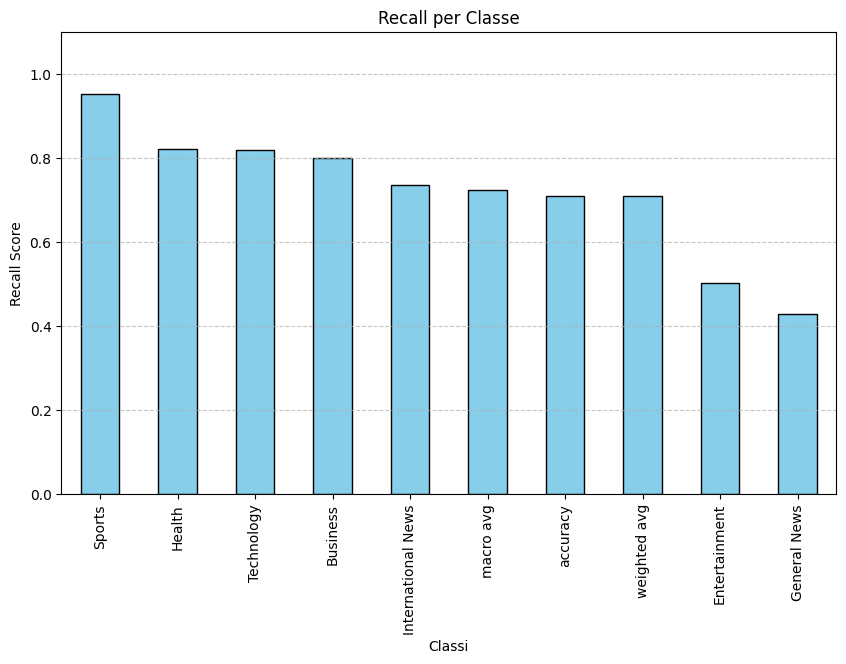

In [20]:
import seaborn as sns
from sklearn.metrics import classification_report

report_dict = classification_report(y_test, y_pred, target_names=labels, output_dict=True)

df_report = pd.DataFrame(report_dict).transpose()
df_recall = df_report['recall'] #recall

plt.figure(figsize=(10, 6))
df_recall.sort_values(ascending=False).plot(kind='bar', color='skyblue', edgecolor='black')

plt.title('Recall per Classe')
plt.ylabel('Recall Score')
plt.xlabel('Classi')
plt.ylim(0, 1.1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

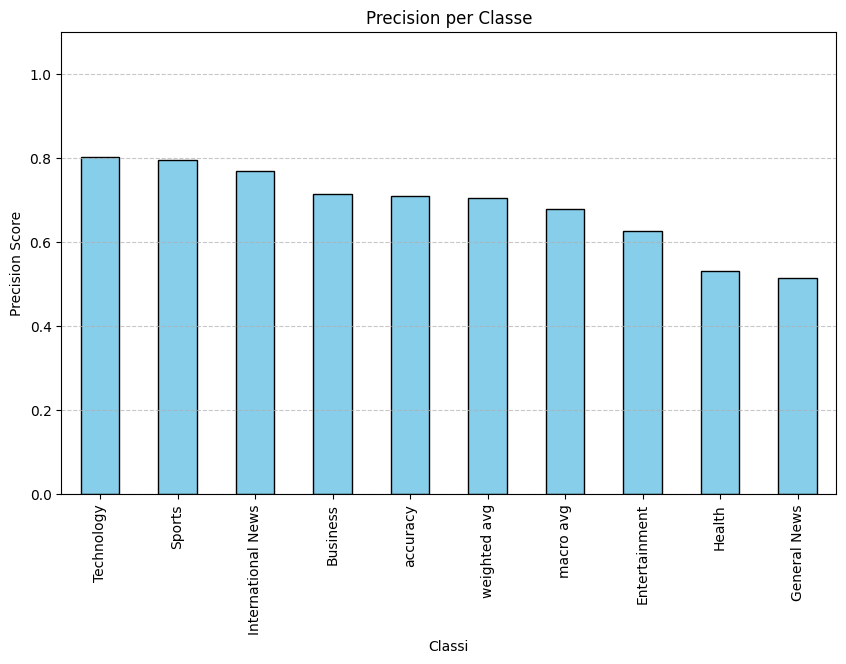

In [21]:
# same as before to undestand precision of the model

df_precision = df_report['precision']

# 3. Plot
plt.figure(figsize=(10, 6))
df_precision.sort_values(ascending=False).plot(kind='bar', color='skyblue', edgecolor='black')

plt.title('Precision per Classe')
plt.ylabel('Precision Score')
plt.xlabel('Classi')
plt.ylim(0, 1.1) 
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [22]:
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = []

for fold, (tr_idx, va_idx) in enumerate(skf.split(X, y)):
    X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
    y_tr, y_va = y[tr_idx], y[va_idx]
    
    final_pipeline.fit(X_tr, y_tr)
    pred = final_pipeline.predict(X_va)
    

    f1 = f1_score(y_va, pred, average="macro")
    scores.append(f1)
    print(f"Fold {fold + 1}: Macro-F1 = {f1:.4f}")

print("mean score", np.mean(scores))

Fold 1: Macro-F1 = 0.6974
Fold 2: Macro-F1 = 0.7002
Fold 3: Macro-F1 = 0.6987
Fold 4: Macro-F1 = 0.6952
Fold 5: Macro-F1 = 0.7012
mean score 0.6985407242847355


# creation of the submission 

In [ ]:
# #building final model and submission.csv


# evaluation = pd.read_csv('winter_project_2026/evaluation.csv')

# final_pipeline.fit(X, y)
# evaluation = cleaner.fit_transform(evaluation)

# evaluation['timestamp'] = pd.to_datetime(evaluation['timestamp'], errors='coerce')
# evaluation['year'] = evaluation['timestamp'].dt.year
# evaluation['year'] = evaluation['year'].fillna(0)
# evaluation['article_len'] = evaluation['article'].fillna('').str.len()

# prediction = final_pipeline.predict(evaluation)

# results = pd.DataFrame({
#     'Id': range(len(prediction)), 
#     'Predicted': prediction   
# })

# # results.to_csv('submission_svm.csv', index=False) #score public 0.715

FileNotFoundError: [Errno 2] No such file or directory: 'winter_project_2026/evaluation.csv'

# MASSIVE GRID SEARCH 

In [ ]:
# #model selection

# from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
# from sklearn.pipeline import Pipeline, FeatureUnion
# from sklearn.feature_extraction.text import TfidfVectorizer
# from sklearn.svm import LinearSVC
# from sklearn.metrics import make_scorer, f1_score
# from sklearn.model_selection import StratifiedShuffleSplit
# from sklearn.model_selection import GridSearchCV
# from sklearn.model_selection import StratifiedKFold


# # svc_model = SVC(C=0.01, tol= 1e-8)

# # linear_svc = LinearSVC(penalty='l2', loss='squared_hinge', dual='auto', tol=0.0001, C=0.5, multi_class='ovr', fit_intercept=True, intercept_scaling=1, class_weight=None, verbose=0, random_state=17, max_iter=2000)


# # param dictionary
# param_dist = {
#     # Tuning SVM (Step diretto nella pipeline principale)
#     "clf__C": [0.1, 0.075, 0.065],

#     # Tuning TF-IDF (Annidato: Pipeline -> ColumnTransformer -> Transformer)
#     "preprocessor_pipeline__preprocessor__text__ngram_range": [(1,3)],
#     "preprocessor_pipeline__preprocessor__text__min_df": [5],
#     "preprocessor_pipeline__preprocessor__text__max_df": [0.15],
#     "preprocessor_pipeline__preprocessor__text__sublinear_tf": [True],
#     "preprocessor_pipeline__preprocessor__text__max_features": [100_000, 200_000],
#     # 'preprocessor_pipeline__preprocessor__text__smooth_idf' : [True],
#     "preprocessor_pipeline__preprocessor__text__binary": [False],
#     # 'preprocessor_pipeline__selector__k' : ['all'],
#     'clf__class_weight' : ['balanced'],

#     # #char preprocessor

#     'preprocessor_pipeline__preprocessor__char__sublinear_tf' : [True],
#     'preprocessor_pipeline__preprocessor__char__ngram_range' : [(3,5)],
#     'preprocessor_pipeline__preprocessor__char__min_df' : [5],
#     'preprocessor_pipeline__preprocessor__char__max_features' : [100_000, 120_000],
#     'preprocessor_pipeline__preprocessor__char__max_df' : [0.06],
#     'preprocessor_pipeline__preprocessor__char__use_idf' : [True],
#     # 'preprocessor_pipeline__preprocessor__char__smooth_idf' : [True, False],
# }


# # cv = StratifiedKFold(n_splits=2, shuffle=True, random_state=17)
# cv = StratifiedKFold(n_splits=5, shuffle = True, random_state=42)
# scorer = make_scorer(f1_score, average="macro")


# # rs = RandomizedSearchCV(
# #     estimator=pipe,
# #     param_distributions=param_dist,
# #     n_iter=20,            # 20-30 è ok; 10 per test rapido
# #     scoring=scorer,
# #     cv=cv,
# #     verbose=2,
# #     n_jobs=1,
# #     random_state=42
# # )



# gs = GridSearchCV(
#     estimator=final_pipeline,
#     param_grid=param_dist, # Qui passi la griglia completa dei parametri
#     scoring= "f1_macro",
#     cv=cv,
#     verbose=3,
#     n_jobs=1,             # Ti consiglio vivamente -1 per usare tutti i core!
# )

# gs.fit(X, y)


# print(f"\n✅ BEST SCORE: {gs.best_score_:.4f}")
# print("🔍 BEST PARAMS:")

# # this is done to better visualize the params
# for k, v in gs.best_params_.items():
#     print(f"   {k} = {v}")

# best_model = gs.best_estimator_


Fitting 5 folds for each of 12 candidates, totalling 60 fits
[CV 1/5] END clf__C=0.1, clf__class_weight=balanced, preprocessor_pipeline__preprocessor__char__max_df=0.06, preprocessor_pipeline__preprocessor__char__max_features=100000, preprocessor_pipeline__preprocessor__char__min_df=5, preprocessor_pipeline__preprocessor__char__ngram_range=(3, 5), preprocessor_pipeline__preprocessor__char__sublinear_tf=True, preprocessor_pipeline__preprocessor__char__use_idf=True, preprocessor_pipeline__preprocessor__text__binary=False, preprocessor_pipeline__preprocessor__text__max_df=0.15, preprocessor_pipeline__preprocessor__text__max_features=100000, preprocessor_pipeline__preprocessor__text__min_df=5, preprocessor_pipeline__preprocessor__text__ngram_range=(1, 3), preprocessor_pipeline__preprocessor__text__sublinear_tf=True;, score=0.697 total time= 1.3min
[CV 2/5] END clf__C=0.1, clf__class_weight=balanced, preprocessor_pipeline__preprocessor__char__max_df=0.06, preprocessor_pipeline__preprocessor

KeyboardInterrupt: 

In [ ]:
# print(gs.best_params_)
# print(gs.best_score_)

{'clf__C': 0.065, 'clf__class_weight': 'balanced', 'preprocessor_pipeline__preprocessor__char__max_df': 0.06, 'preprocessor_pipeline__preprocessor__char__max_features': 120000, 'preprocessor_pipeline__preprocessor__char__min_df': 5, 'preprocessor_pipeline__preprocessor__char__ngram_range': (3, 5), 'preprocessor_pipeline__preprocessor__char__sublinear_tf': True, 'preprocessor_pipeline__preprocessor__char__use_idf': True, 'preprocessor_pipeline__preprocessor__text__binary': False, 'preprocessor_pipeline__preprocessor__text__max_df': 0.15, 'preprocessor_pipeline__preprocessor__text__max_features': 100000, 'preprocessor_pipeline__preprocessor__text__min_df': 5, 'preprocessor_pipeline__preprocessor__text__ngram_range': (1, 3), 'preprocessor_pipeline__preprocessor__text__sublinear_tf': True}
0.6988347362519549


# {'clf__C': 0.065, 'clf__class_weight': 'balanced', 'preprocessor_pipeline__preprocessor__char__max_df': 0.1, 'preprocessor_pipeline__preprocessor__char__max_features': 120000, 'preprocessor_pipeline__preprocessor__char__min_df': 5, 'preprocessor_pipeline__preprocessor__char__ngram_range': (3, 5), 'preprocessor_pipeline__preprocessor__char__sublinear_tf': True, 'preprocessor_pipeline__preprocessor__char__use_idf': True, 'preprocessor_pipeline__preprocessor__text__binary': False, 'preprocessor_pipeline__preprocessor__text__max_df': 0.15, 'preprocessor_pipeline__preprocessor__text__max_features': 20000, 'preprocessor_pipeline__preprocessor__text__min_df': 5, 'preprocessor_pipeline__preprocessor__text__ngram_range': (1, 3), 'preprocessor_pipeline__preprocessor__text__sublinear_tf': True}
0.7003862085959536
0.6936248546536922
0.694123439144343

# SUBMISSION CON PARAMETRI MIGLIORI

In [ ]:
# final_pipeline = pipe.set_params(**gs.best_params_)
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# final_pipeline.fit(X_train, y_train)

# y_pred = final_pipeline.predict(X_test)

# print(f1_score(y_pred, y_test, average='macro'))

# evaluation = pd.read_csv('winter_project_2026/evaluation.csv')

# final_pipeline.fit(X, y)
# evaluation = cleaner.fit_transform(evaluation)

# evaluation['timestamp'] = pd.to_datetime(evaluation['timestamp'], errors='coerce')
# evaluation['year'] = evaluation['timestamp'].dt.year
# evaluation['year'] = evaluation['year'].fillna(0)
# evaluation['article_len'] = evaluation['article'].fillna('').str.len()
# prediction = final_pipeline.predict(evaluation)

# results = pd.DataFrame({
#     'Id': range(len(prediction)), 
#     'Predicted': prediction
# })

# results.to_csv('submission_svm_best_param.csv', index=False)

0.6943663408664509
